# Notebook Flow Summary

This notebook performs SKU risk segmentation, hierarchical ABC analysis, hierarchical RFM analysis (product hierarchy only), and final combined ABC-RFM visualizations.

```mermaid
flowchart TD
    A[Load Order Data] --> B[Build SKU Risk Table]
    B --> B1[Unique Customer Count per SKU]
    B --> B2[SKU Total Order Amount]
    B --> B3[Customer Concentration Ratio]

    B1 --> C[Risk Category Heuristic]
    C --> C1[High: customers < 3]
    C --> C2[Medium: customers 3-5]
    C --> C3[Low: customers > 5]

    B2 --> D[Risk Category Business]
    B3 --> D
    D --> D1[High: low customer base + high amount/concentration]
    D --> D2[Medium: moderate customer base + moderate amount/concentration]
    D --> D3[Low: otherwise]

    B --> E[Manager Summary]
    E --> E1[Heuristic vs Business Matrix]
    E --> E2[Top High Business Risk SKUs]
    E --> E3[Export sku_risk_summary.csv]

    A --> F[Hierarchical ABC Analysis]
    F --> F1[Category -> Group -> Subgroup -> SKU]
    F --> F2[ABC Classes: A/B/C by contribution]

    F --> G[ABC Visualizations]
    G --> G1[Pareto Charts]
    G --> G2[Sankey / Treemap / Sunburst with % Contribution]

    G --> H[Hierarchical RFM Analysis]
    H --> H1[Category -> Group -> Subgroup -> SKU]
    H --> H2[R, F, M scores by hierarchy level]
    H --> H3[RFM Categories: Runner, Repeater, Dormant, Slow Mover]
    H --> H4[Export hierarchical_rfm_summary.csv]

    H --> I[Final ABC-RFM Combined Visualizations]
    I --> I1[Level + hierarchy filters]
    I --> I2[Scatter / Stacked / Grouped / Heatmap]
```

## Outputs
- `sku_customer_risk_df`: SKU risk dataset with `Risk_Category_heuristic` and `Risk_Category_business`
- `hierarchical_abc_df`: Hierarchical ABC output
- `hierarchical_abc_view_df`: ABC output with risk labels for view only
- `hierarchical_rfm_df`: Hierarchical RFM output (product hierarchy only)
- `notebook/sku_risk_summary.csv`: Exported risk summary
- `notebook/hierarchical_rfm_summary.csv`: Exported hierarchical RFM summary

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# ==========================================================
# Load  Order Data
# ==========================================================

df = pd.read_excel(
    "Order Intake Incl Amounts.xlsx",
    # sheet_name="M1"
    dtype={"OriginalOA_Date": object}

)

df["OriginalOA_Date"] = df["OriginalOA_Date"].apply(

    lambda x: (

        pd.Timestamp("1899-12-30") + pd.to_timedelta(int(x), unit="D")

        if isinstance(x, (int, float))

        else pd.to_datetime(x)

    )

)
output_file = "sheet_m2h2_sku_final_abc_rfm_risk.csv"
# output_file = "sheet_m1_sku_final_abc_rfm_risk.csv"
hierarchical_rfm_export_path = "sheet_m2h2_hierarchical_rfm_summary.csv"
# hierarchical_rfm_export_path = "sheet_m1_hierarchical_rfm_summary.csv"

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (25571, 13)


,OA_No,OriginalOA_Date,Item_Code,Item_Name,Type,Party_Code,Order_Qty,Order_Amount,Item_Category_Code,Product Group Code,Product_SubGroup_Code,Lead Time,Lead Time for Stocking
0,27001927,2026-06-30,NS.CA0155.424601.0003,NON STANDARD GUIDE PILLAR,M1,CA0155,2,2604.0,N03,2237.0,M1-223060,28,49
1,27001936,2026-06-30,2016.213.00.052.030.2,52 CAM UNIT,M1,CP0169,1,17739.8,N10,8273.0,M1-827311,21,42
2,27001942,2026-06-30,2480.011.00500.1,GAS SPRING FLANGE,M1,CD0048,8,3210.8,N07,8289.0,M1-828905,28,49
3,27001942,2026-06-30,2480.055.01500,GAS SPRING FLANGE - ROUND TYPE,M1,CD0048,4,6729.8,N07,8289.0,M1-828904,21,42
4,27001944,2026-06-30,2480.057.01500,GAS SPRING FIXING DEVICE - SQUARE TYPE,M1,CD0048,4,7838.4,N07,8289.0,M1-828904,21,42


In [ ]:
# # ==========================================================
# # Summary: Heuristic vs Business Risk
# # ==========================================================

# summary_cols = [
#     sku_col,
#     "Unique_Customer_Count",
#     "SKU_Total_Order_Amount",
#     "Customer_Concentration_Ratio",
#     "Risk_Category_heuristic",
#     "Risk_Category_business",
# ]

# # 1) Cross-tab matrix: Heuristic category vs Business category
# risk_matrix = pd.crosstab(
#     sku_customer_risk_df["Risk_Category_heuristic"],
#     sku_customer_risk_df["Risk_Category_business"],
#     margins=True,
#     margins_name="Total",
# )

# print("\nRisk Comparison Matrix (Heuristic vs Business):")
# display(risk_matrix)

# # 2) Top High Business-Risk SKUs by total order amount
# top_high_business_risk = (
#     sku_customer_risk_df[
#         sku_customer_risk_df["Risk_Category_business"] == "High Risk"
#     ][summary_cols]
#     .sort_values("SKU_Total_Order_Amount", ascending=False)
#     .head(25)
# )

# print("\nTop 25 High Business-Risk SKUs by Total Order Amount:")
# display(top_high_business_risk)

# # 3) Export full SKU risk table for sharing/review
# export_path = "sku_risk_summary.csv"
# sku_customer_risk_df[summary_cols].to_csv(export_path, index=False)
# print(f"\nExported risk summary to: {export_path}")

In [4]:
import pandas as pd

product_group_col = "Product Group Code"
customer_col = "Party_Code"
amount_col = "Order_Amount"

# ==========================================================
# Internal Customer Master
# ==========================================================

customer_master = pd.DataFrame({
    "Party_Code": [
        "CF008",
        "CF028",
        "CL0049",
        "CO015",
        "CF038",
        "CF039",
    ],
    "Customer_Name": [
        "FIBRO GMBH",
        "FIBRO Korea",
        "Laepple Taicang",
        "O.M.C.R. srl",
        "FIBRO Inc.",
        "FIBRO Malaysia",
    ],
    "Customer_Type": [
        "Internal",
        "Internal",
        "Internal",
        "Internal",
        "Internal",
        "Internal",
    ],
})

# ==========================================================
# Customer-wise Sales within each Product Group
# ==========================================================

group_customer = (
    df.groupby([product_group_col, customer_col], as_index=False)[amount_col]
      .sum()
      .rename(columns={amount_col: "Customer_Order_Amount"})
)

# Join Customer Master
group_customer = group_customer.merge(
    customer_master,
    on="Party_Code",
    how="left"
)

# Customers not in the master are External
group_customer["Customer_Type"] = (
    group_customer["Customer_Type"]
    .fillna("External")
)

group_customer["Customer_Name"] = (
    group_customer["Customer_Name"]
    .fillna(group_customer["Party_Code"])
)

# ==========================================================
# Largest Customer in each Product Group
# ==========================================================

largest_customer = (
    group_customer.loc[
        group_customer.groupby(product_group_col)["Customer_Order_Amount"].idxmax(),
        [
            product_group_col,
            customer_col,
            "Customer_Name",
            "Customer_Type",
            "Customer_Order_Amount",
        ]
    ]
    .rename(columns={
        customer_col: "Largest_Customer_Code",
        "Customer_Name": "Largest_Customer_Name",
        "Customer_Type": "Largest_Customer_Type",
        "Customer_Order_Amount": "Largest_Customer_Sales",
    })
)

# ==========================================================
# Product Risk Summary
# ==========================================================

product_risk_summary = (
    group_customer
    .groupby(product_group_col)
    .agg(
        Unique_Customers=(customer_col, "nunique"),
        Total_Sales=("Customer_Order_Amount", "sum"),
        Min_Customer_Sales=("Customer_Order_Amount", "min"),
        Avg_Customer_Sales=("Customer_Order_Amount", "mean"),
        Median_Customer_Sales=("Customer_Order_Amount", "median"),
    )
    .reset_index()
    .merge(largest_customer, on=product_group_col, how="left")
)

# ==========================================================
# Customer Concentration (%)
# ==========================================================

product_risk_summary["Customer_Concentration"] = (
    product_risk_summary["Largest_Customer_Sales"]
    / product_risk_summary["Total_Sales"]
    * 100
).round(2)

# ==========================================================
# Purchase Range
# ==========================================================

product_risk_summary["Purchase_Range"] = (
    product_risk_summary["Min_Customer_Sales"].round().astype(int).map("{:,}".format)
    + " - "
    + product_risk_summary["Largest_Customer_Sales"].round().astype(int).map("{:,}".format)
)

# ==========================================================
# Risk Classification
# ==========================================================

def classify_product_group(row):

    concentration = row["Customer_Concentration"]
    customer_type = row["Largest_Customer_Type"]

    # External Customers
    if customer_type == "External":

        if concentration >= 80:
            return "High_Risk_External"

        elif concentration >= 60:
            return "Medium_Risk_External"

        else:
            return "Low_Risk_External"

    # Internal Customers
    else:

        # Internal customers are capped at Medium Risk
        if concentration >= 60:
            return "Medium_Risk_Internal"

        else:
            return "Low_Risk_Internal"


product_risk_summary["Risk_Category"] = (
    product_risk_summary.apply(classify_product_group, axis=1)
)

# ==========================================================
# Formatting
# ==========================================================

amount_cols = [
    "Total_Sales",
    "Largest_Customer_Sales",
    "Min_Customer_Sales",
    "Avg_Customer_Sales",
    "Median_Customer_Sales",
]

for col in amount_cols:
    product_risk_summary[col] = (
        product_risk_summary[col]
        .round()
        .astype(int)
        .map("{:,}".format)
    )

product_risk_summary["Customer_Concentration"] = (
    product_risk_summary["Customer_Concentration"]
    .map("{:.2f}%".format)
)

# ==========================================================
# Reorder Columns
# ==========================================================

product_risk_summary = product_risk_summary[
    [
        product_group_col,
        "Unique_Customers",
        "Total_Sales",
        "Largest_Customer_Code",
        "Largest_Customer_Name",
        "Largest_Customer_Type",
        "Largest_Customer_Sales",
        "Customer_Concentration",
        "Min_Customer_Sales",
        "Avg_Customer_Sales",
        "Median_Customer_Sales",
        "Purchase_Range",
        "Risk_Category",
    ]
]

# ==========================================================
# Export
# ==========================================================

product_risk_summary.to_csv("product_risk_summary.csv", index=False)

product_risk_summary

,Product Group Code,Unique_Customers,Total_Sales,Largest_Customer_Code,Largest_Customer_Name,Largest_Customer_Type,Largest_Customer_Sales,Customer_Concentration,Min_Customer_Sales,Avg_Customer_Sales,Median_Customer_Sales,Purchase_Range,Risk_Category
0,1201.0,71,"41,087,726",CL001,CL001,External,"7,032,760",17.12%,18,"578,700","64,500","18 - 7,032,760",Low_Risk_External
1,1202.0,1,"12,004",CF008,FIBRO GMBH,Internal,"12,004",100.00%,"12,004","12,004","12,004","12,004 - 12,004",Medium_Risk_Internal
2,1203.0,22,"8,122,648",CS0231,CS0231,External,"4,483,300",55.20%,990,"369,211","27,800","990 - 4,483,300",Low_Risk_External
3,1204.0,1,"9,723",CF008,FIBRO GMBH,Internal,"9,723",100.00%,"9,723","9,723","9,723","9,723 - 9,723",Medium_Risk_Internal
4,1217.0,24,"3,566,404",CV010,CV010,External,"2,576,500",72.24%,163,"148,600","6,545","163 - 2,576,500",Medium_Risk_External
5,1230.0,63,"4,904,830",CS0231,CS0231,External,"968,475",19.75%,"1,818","77,854","20,242","1,818 - 968,475",Low_Risk_External
6,1238.0,4,"43,776",CR0109,CR0109,External,"27,729",63.34%,"4,452","10,944","5,798","4,452 - 27,729",Medium_Risk_External
7,2220.0,1,"13,224",CT00162,CT00162,External,"13,224",100.00%,"13,224","13,224","13,224","13,224 - 13,224",High_Risk_External
8,2222.0,8,"2,477,482",CT006,CT006,External,"1,297,940",52.39%,"2,196","309,685","131,122","2,196 - 1,297,940",Low_Risk_External
9,2223.0,5,"21,038",CF008,FIBRO GMBH,Internal,"10,741",51.06%,186,"4,208","4,296","186 - 10,741",Low_Risk_Internal


In [5]:
# ==========================================================
# Select Columns Required for Hierarchical ABC Analysis
# ==========================================================
#
# Hierarchy
#
# Item Category
#       ↓
# Product Group
#       ↓
# Product Sub Group
#       ↓
# SKU
#
# Order Amount is used as the business value.
# ==========================================================

abc_data = df[
    [
        "Item_Category_Code",
        "Product Group Code",
        "Product_SubGroup_Code",
        "Item_Code",
        "Item_Name",
        "Order_Amount"
    ]
].copy()

abc_data.head()

,Item_Category_Code,Product Group Code,Product_SubGroup_Code,Item_Code,Item_Name,Order_Amount
0,N03,2237.0,M1-223060,NS.CA0155.424601.0003,NON STANDARD GUIDE PILLAR,2604.0
1,N10,8273.0,M1-827311,2016.213.00.052.030.2,52 CAM UNIT,17739.8
2,N07,8289.0,M1-828905,2480.011.00500.1,GAS SPRING FLANGE,3210.8
3,N07,8289.0,M1-828904,2480.055.01500,GAS SPRING FLANGE - ROUND TYPE,6729.8
4,N07,8289.0,M1-828904,2480.057.01500,GAS SPRING FIXING DEVICE - SQUARE TYPE,7838.4


In [6]:
# ==========================================================
# Function : ABC Classification
# ==========================================================
#
# Performs Pareto-based ABC classification.
#
# A : First 80% cumulative contribution
# B : Next 15%
# C : Remaining 5%
# ==========================================================

def calculate_abc(summary):

    summary = summary.sort_values(
        "Total_Order_Amount",
        ascending=False
    ).reset_index(drop=True)

    summary["Contribution (%)"] = (
        summary["Total_Order_Amount"]
        /
        summary["Total_Order_Amount"].sum()
        * 100
    )

    summary["Cumulative Contribution (%)"] = (
        summary["Contribution (%)"]
        .cumsum()
    )

    def classify(cum):

        if cum <= 80:
            return "A"

        elif cum <= 95:
            return "B"

        else:
            return "C"

    summary["ABC_Class"] = (
        summary["Cumulative Contribution (%)"]
        .apply(classify)
    )

    return summary

In [7]:
# ==========================================================
# Function : Hierarchical ABC Analysis
# ==========================================================
#
# This function performs ABC Analysis level by level.
#
# Item Category
#       ↓
# Product Group
#       ↓
# Product Sub Group
#       ↓
# SKU
#
# Each child level is compared ONLY within its parent.
# ==========================================================

def hierarchical_abc(data):

    results = []

    # -------------------------------
    # Category Level
    # -------------------------------

    category_summary = (
        data
        .groupby(
            "Item_Category_Code",
            as_index=False
        )["Order_Amount"]
        .sum()
        .rename(
            columns={
                "Order_Amount":"Total_Order_Amount"
            }
        )
    )

    category_summary = calculate_abc(category_summary)

    # Process each Category independently

    for _, cat in category_summary.iterrows():

        category = cat["Item_Category_Code"]

        category_data = (
            data[
                data["Item_Category_Code"] == category
            ]
        )

        # -------------------------------
        # Product Group Level
        # -------------------------------

        group_summary = (
            category_data
            .groupby(
                "Product Group Code",
                as_index=False
            )["Order_Amount"]
            .sum()
            .rename(
                columns={
                    "Order_Amount":"Total_Order_Amount"
                }
            )
        )

        group_summary = calculate_abc(group_summary)

        for _, grp in group_summary.iterrows():

            group = grp["Product Group Code"]

            group_data = (
                category_data[
                    category_data["Product Group Code"] == group
                ]
            )

            # -------------------------------
            # Product Sub Group
            # -------------------------------

            subgroup_summary = (
                group_data
                .groupby(
                    "Product_SubGroup_Code",
                    as_index=False
                )["Order_Amount"]
                .sum()
                .rename(
                    columns={
                        "Order_Amount":"Total_Order_Amount"
                    }
                )
            )

            subgroup_summary = calculate_abc(subgroup_summary)

            for _, sub in subgroup_summary.iterrows():

                subgroup = sub["Product_SubGroup_Code"]

                subgroup_data = (
                    group_data[
                        group_data["Product_SubGroup_Code"] == subgroup
                    ]
                )

                # -------------------------------
                # SKU Level
                # -------------------------------

                sku_summary = (
                    subgroup_data
                    .groupby(
                        [
                            "Item_Code",
                            "Item_Name"
                        ],
                        as_index=False
                    )["Order_Amount"]
                    .sum()
                    .rename(
                        columns={
                            "Order_Amount":"Total_Order_Amount"
                        }
                    )
                )

                sku_summary = calculate_abc(sku_summary)

                sku_summary["Item_Category_Code"] = category
                sku_summary["Category_ABC"] = cat["ABC_Class"]

                sku_summary["Product Group Code"] = group
                sku_summary["Product_Group_ABC"] = grp["ABC_Class"]

                sku_summary["Product_SubGroup_Code"] = subgroup
                sku_summary["Product_SubGroup_ABC"] = sub["ABC_Class"]

                results.append(sku_summary)

    final_df = (
        pd.concat(
            results,
            ignore_index=True
        )
    )

    return final_df

In [8]:
product_risk_summary.columns

Index(['Product Group Code', 'Unique_Customers', 'Total_Sales',
       'Largest_Customer_Code', 'Largest_Customer_Name',
       'Largest_Customer_Type', 'Largest_Customer_Sales',
       'Customer_Concentration', 'Min_Customer_Sales', 'Avg_Customer_Sales',
       'Median_Customer_Sales', 'Purchase_Range', 'Risk_Category'],
      dtype='object')

In [9]:
# ==========================================================
# Run Hierarchical ABC Analysis
# ==========================================================

hierarchical_abc_df = hierarchical_abc(
    abc_data
)

# View-only merge: add risk labels for inspection without changing
# the actual ABC calculation dataframe used in analysis.
risk_view_cols = [
'Product Group Code', 'Unique_Customers', 'Total_Sales',
       'Min_Customer_Sales', 'Avg_Customer_Sales', 'Median_Customer_Sales',
       'Largest_Customer_Name', 'Largest_Customer_Sales',
       'Customer_Concentration', 'Purchase_Range', 'Risk_Category'
]

hierarchical_abc_view_df = (
    hierarchical_abc_df
    .merge(
        product_risk_summary[risk_view_cols],
        on="Product Group Code",
        how="left"
    )
)

hierarchical_abc_view_df.head()

,Item_Code,Item_Name,Total_Order_Amount,Contribution (%),Cumulative Contribution (%),ABC_Class,Item_Category_Code,Category_ABC,Product Group Code,Product_Group_ABC,...,Unique_Customers,Total_Sales,Min_Customer_Sales,Avg_Customer_Sales,Median_Customer_Sales,Largest_Customer_Name,Largest_Customer_Sales,Customer_Concentration,Purchase_Range,Risk_Category
0,2016.202.20.200.055.1,CAM UNIT FOR COMPRESSION SPRING,4541904.40,5.643655,5.643655,A,N10,A,8273.0,C,...,102,"120,937,949","1,560","1,185,666","191,920",CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External
1,2016.204.00.150.032.1,AERIAL CAM UNIT,3586678.18,4.456715,10.100370,A,N10,A,8273.0,C,...,102,"120,937,949","1,560","1,185,666","191,920",CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External
2,2016.202.30.200.065.1,CAM UNIT WITH COMPRESSION SPRING,2771675.00,3.444013,13.544383,A,N10,A,8273.0,C,...,102,"120,937,949","1,560","1,185,666","191,920",CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External
3,2016.202.15.200.050.1,CAM UNIT WITH COMPRESSION SPRING,2647000.00,3.289095,16.833478,A,N10,A,8273.0,C,...,102,"120,937,949","1,560","1,185,666","191,920",CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External
4,2016.204.30.080.054.1,AERIAL CAM UNIT,2404701.56,2.988021,19.821500,A,N10,A,8273.0,C,...,102,"120,937,949","1,560","1,185,666","191,920",CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External


In [10]:
# Product Group risk brought down to SKU level
risk_cols = [
    "Product Group Code",
    "Unique_Customers",
    "Largest_Customer_Name",
    "Largest_Customer_Sales",
    "Customer_Concentration",
    "Purchase_Range",
    "Risk_Category",
]

sku_customer_risk_df = (
    df[["Item_Code", "Product Group Code"]]
    .drop_duplicates()
    .merge(
        product_risk_summary[risk_cols],
        on="Product Group Code",
        how="left"
    )
)

# View-only merge: add risk labels for inspection
hierarchical_abc_view_df = (
    hierarchical_abc_df
    .merge(
        sku_customer_risk_df,
        on="Item_Code",
        how="left"
    )
)

hierarchical_abc_view_df.head()

,Item_Code,Item_Name,Total_Order_Amount,Contribution (%),Cumulative Contribution (%),ABC_Class,Item_Category_Code,Category_ABC,Product Group Code_x,Product_Group_ABC,Product_SubGroup_Code,Product_SubGroup_ABC,Product Group Code_y,Unique_Customers,Largest_Customer_Name,Largest_Customer_Sales,Customer_Concentration,Purchase_Range,Risk_Category
0,2016.202.20.200.055.1,CAM UNIT FOR COMPRESSION SPRING,4541904.40,5.643655,5.643655,A,N10,A,8273.0,C,M1-827340,A,8273.0,102.0,CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External
1,2016.204.00.150.032.1,AERIAL CAM UNIT,3586678.18,4.456715,10.100370,A,N10,A,8273.0,C,M1-827340,A,8273.0,102.0,CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External
2,2016.202.30.200.065.1,CAM UNIT WITH COMPRESSION SPRING,2771675.00,3.444013,13.544383,A,N10,A,8273.0,C,M1-827340,A,8273.0,102.0,CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External
3,2016.202.15.200.050.1,CAM UNIT WITH COMPRESSION SPRING,2647000.00,3.289095,16.833478,A,N10,A,8273.0,C,M1-827340,A,8273.0,102.0,CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External
4,2016.204.30.080.054.1,AERIAL CAM UNIT,2404701.56,2.988021,19.821500,A,N10,A,8273.0,C,M1-827340,A,8273.0,102.0,CP028,"17,730,629",14.66%,"1,560 - 17,730,629",Low_Risk_External


In [11]:
hierarchical_abc_df.columns

Index(['Item_Code', 'Item_Name', 'Total_Order_Amount', 'Contribution (%)',
       'Cumulative Contribution (%)', 'ABC_Class', 'Item_Category_Code',
       'Category_ABC', 'Product Group Code', 'Product_Group_ABC',
       'Product_SubGroup_Code', 'Product_SubGroup_ABC'],
      dtype='object')

In [12]:
# ==========================================================
# Function: Plot Pareto Chart
# ==========================================================

def plot_pareto(summary_df, level_name):

    fig, ax1 = plt.subplots(figsize=(12,6))

    # Bar Plot
    ax1.bar(
        summary_df.iloc[:,0].astype(str),
        summary_df["Total_Order_Amount"],
        color="steelblue"
    )

    ax1.set_ylabel("Order Amount")
    ax1.set_xlabel(level_name)

    plt.xticks(rotation=90)

    # Line Plot
    ax2 = ax1.twinx()

    ax2.plot(
        summary_df.iloc[:,0].astype(str),
        summary_df["Cumulative Contribution (%)"],
        color="red",
        marker="o",
        linewidth=2
    )

    ax2.axhline(
        y=80,
        color="green",
        linestyle="--",
        label="80%"
    )

    ax2.axhline(
        y=95,
        color="orange",
        linestyle="--",
        label="95%"
    )

    ax2.set_ylabel("Cumulative Contribution (%)")

    plt.title(f"Pareto Chart - {level_name}")

    plt.tight_layout()

    plt.show()

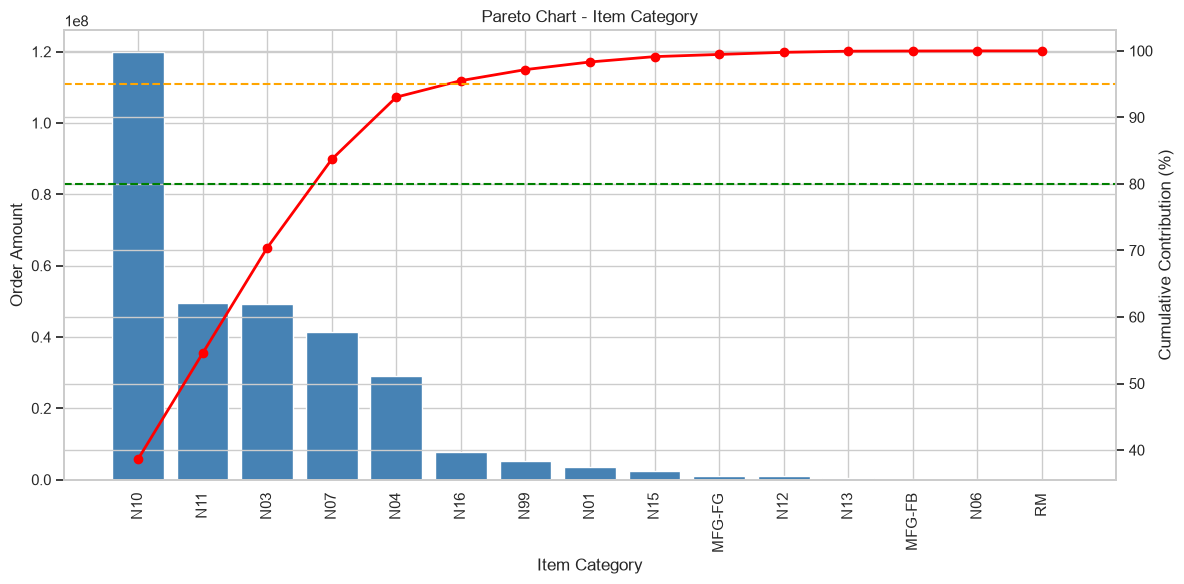

In [13]:
category_summary = (
    hierarchical_abc_df
    .groupby(
        ["Item_Category_Code", "Category_ABC"],
        as_index=False
    )
    .agg({
        "Total_Order_Amount":"sum"
    })
)

category_summary = calculate_abc(category_summary)

plot_pareto(category_summary, "Item Category")







In [14]:
import plotly.graph_objects as go
import pandas as pd

# ==========================================================
# Create links
# ==========================================================

# Category → Product Group
cat_group = (
    hierarchical_abc_df
    .groupby(
        ["Item_Category_Code", "Product Group Code"],
        as_index=False
    )["Total_Order_Amount"]
    .sum()
)

cat_group.columns = ["source", "target", "value"]

# Product Group → Product Sub Group
group_subgroup = (
    hierarchical_abc_df
    .groupby(
        ["Product Group Code", "Product_SubGroup_Code"],
        as_index=False
    )["Total_Order_Amount"]
    .sum()
)

group_subgroup.columns = ["source", "target", "value"]

# Combine both levels
links = pd.concat([cat_group, group_subgroup], ignore_index=True)

# ==========================================================
# Create nodes
# ==========================================================

nodes = pd.unique(
    pd.concat(
        [links["source"], links["target"]],
        ignore_index=True
    )
)

node_map = {node: i for i, node in enumerate(nodes)}

links["source_id"] = links["source"].map(node_map)
links["target_id"] = links["target"].map(node_map)

# ==========================================================
# Sankey Diagram
# ==========================================================

fig = go.Figure(
    go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=nodes.tolist()
        ),
        link=dict(
            source=links["source_id"],
            target=links["target_id"],
            value=links["value"]
        )
    )
)

fig.update_layout(
    title="Hierarchical Flow: Category → Product Group → Product Sub Group",
    font_size=12,
    height=700,
    width=1200
)

fig.show()

In [15]:
import plotly.express as px

hierarchy_cols = [
    "Item_Category_Code",
    "Product Group Code",
    "Product_SubGroup_Code",
]

hierarchy_df = (
    hierarchical_abc_df
    .groupby(hierarchy_cols, as_index=False)["Total_Order_Amount"]
    .sum()
)

total_amount = hierarchy_df["Total_Order_Amount"].sum()
hierarchy_df["Contribution_%"] = (
    hierarchy_df["Total_Order_Amount"] / total_amount * 100
)

fig = px.treemap(
    hierarchy_df,
    path=hierarchy_cols,
    values="Total_Order_Amount",
    color="Contribution_%",
    color_continuous_scale="Blues",
    hover_data={
        "Total_Order_Amount": ":,.2f",
        "Contribution_%": ":.2f",
    },
    title="Hierarchy of Order Amount with % Contribution"
 )

fig.update_traces(textinfo="label+percent root+value")

fig.update_layout(
    width=1200,
    height=800
)

fig.show()

In [16]:
import plotly.express as px

hierarchy_cols = [
    "Item_Category_Code",
    "Product Group Code",
    "Product_SubGroup_Code",
]

hierarchy_df = (
    hierarchical_abc_df
    .groupby(hierarchy_cols, as_index=False)["Total_Order_Amount"]
    .sum()
)

total_amount = hierarchy_df["Total_Order_Amount"].sum()
hierarchy_df["Contribution_%"] = (
    hierarchy_df["Total_Order_Amount"] / total_amount * 100
)

fig = px.sunburst(
    hierarchy_df,
    path=hierarchy_cols,
    values="Total_Order_Amount",
    color="Contribution_%",
    color_continuous_scale="Blues",
    hover_data={
        "Total_Order_Amount": ":,.2f",
        "Contribution_%": ":.2f",
    },
    title="Hierarchy of Order Amount with % Contribution"
 )

fig.update_traces(textinfo="label+percent root+value")

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

## Hierarchical RFM Analysis

This section builds a product-hierarchy RFM summary for each level below:

Item Category -> Product Group -> Product Sub Group -> SKU

The output includes:
- `RFM_Category`: Runner, Repeater, Dormant, Slow Mover
- `ABC_Class`
- `Risk_Category_heuristic`
- `Risk_Category_business`

This is a product-level hierarchy analysis only, not a customer-level RFM model.

In [17]:
# ==========================================================
# Build Hierarchical RFM Table (Category -> Group -> Subgroup -> SKU)
# with Unique Customer Count
# NOTE: Business risk is NOT added to hierarchical_rfm_df
# ==========================================================

hierarchy_cols = [
    "Item_Category_Code",
    "Product Group Code",
    "Product_SubGroup_Code",
    "Item_Code",
]
rfm_date_col_candidates = ["OriginalOA_Date", "OA_Date", "Order_Date", "Date"]
rfm_amount_col = "Order_Amount"
rfm_order_id_col_candidates = ["OA_No", "Order_No", "Order_ID"]
customer_col_candidates = ["Party_Code", "Customer_Code", "Client_Code"]

for col in hierarchy_cols:
    if col not in df.columns:
        raise KeyError(f"Missing hierarchy column: {col}")

matching_rfm_date_cols = [c for c in rfm_date_col_candidates if c in df.columns]
matching_rfm_order_id_cols = [c for c in rfm_order_id_col_candidates if c in df.columns]
matching_customer_cols = [c for c in customer_col_candidates if c in df.columns]

if not matching_rfm_date_cols:
    raise KeyError(f"No order-date column found. Checked: {rfm_date_col_candidates}")
if rfm_amount_col not in df.columns:
    raise KeyError(f"Missing required amount column: {rfm_amount_col}")
if not matching_customer_cols:
    raise KeyError(f"No customer column found. Checked: {customer_col_candidates}")

rfm_date_col = matching_rfm_date_cols[0]
rfm_order_id_col = matching_rfm_order_id_cols[0] if matching_rfm_order_id_cols else None
customer_col = matching_customer_cols[0]

select_cols = hierarchy_cols + [customer_col, rfm_date_col, rfm_amount_col]
if rfm_order_id_col:
    select_cols.append(rfm_order_id_col)

product_rfm_base = df[select_cols].copy()
product_rfm_base = product_rfm_base.dropna(subset=hierarchy_cols + [customer_col, rfm_date_col, rfm_amount_col])

def parse_mixed_order_date(series: pd.Series) -> pd.Series:
    numeric_vals = pd.to_numeric(series, errors="coerce")
    parsed = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")

    # Excel date serials are day counts from 1899-12-30.
    is_excel_serial = numeric_vals.between(20000, 70000)
    if is_excel_serial.any():
        parsed.loc[is_excel_serial] = pd.to_datetime(
            numeric_vals.loc[is_excel_serial],
            unit="D",
            origin="1899-12-30",
            errors="coerce",
        )

    # Parse remaining values as text/datetime with day-first support.
    remaining = ~is_excel_serial
    if remaining.any():
        parsed.loc[remaining] = pd.to_datetime(
            series.loc[remaining],
            errors="coerce",
            dayfirst=True,
        )

    return parsed

product_rfm_base[rfm_date_col] = parse_mixed_order_date(product_rfm_base[rfm_date_col])
product_rfm_base = product_rfm_base.dropna(subset=[rfm_date_col])

# Drop clearly invalid future dates if any.
product_rfm_base = product_rfm_base[
    product_rfm_base[rfm_date_col] <= (pd.Timestamp.today() + pd.Timedelta(days=7))
]

for col in hierarchy_cols:
    product_rfm_base[col] = product_rfm_base[col].astype("string")

snapshot_date = product_rfm_base[rfm_date_col].max() + pd.Timedelta(days=1)

def _assign_rfm_category(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Runner"
    if r >= 3 and f >= 3 and m >= 3:
        return "Repeater"
    if r <= 2 and f <= 2 and m <= 2:
        return "Dormant"
    return "Slow Mover"

def _compute_level_rfm(base_df, entity_col):
    if rfm_order_id_col:
        level_rfm = base_df.groupby(entity_col, as_index=False).agg(
            Recency=(rfm_date_col, lambda s: (snapshot_date - s.max()).days),
            Frequency=(rfm_order_id_col, "nunique"),
            Monetary=(rfm_amount_col, "sum"),
            Unique_Customer_Count=(customer_col, "nunique"),
        )
    else:
        level_rfm = base_df.groupby(entity_col, as_index=False).agg(
            Recency=(rfm_date_col, lambda s: (snapshot_date - s.max()).days),
            Frequency=(entity_col, "size"),
            Monetary=(rfm_amount_col, "sum"),
            Unique_Customer_Count=(customer_col, "nunique"),
        )

    level_rfm["R_Score"] = pd.qcut(
        level_rfm["Recency"].rank(method="first", ascending=True),
        5,
        labels=[5, 4, 3, 2, 1],
    ).astype(int)
    level_rfm["F_Score"] = pd.qcut(
        level_rfm["Frequency"].rank(method="first", ascending=True),
        5,
        labels=[1, 2, 3, 4, 5],
    ).astype(int)
    level_rfm["M_Score"] = pd.qcut(
        level_rfm["Monetary"].rank(method="first", ascending=True),
        5,
        labels=[1, 2, 3, 4, 5],
    ).astype(int)

    level_rfm["RFM_Score"] = (
        level_rfm["R_Score"].astype(str)
        + level_rfm["F_Score"].astype(str)
        + level_rfm["M_Score"].astype(str)
    )
    level_rfm["RFM_Category"] = level_rfm.apply(_assign_rfm_category, axis=1)
    return level_rfm

level_spec = [
    ("Category", "Item_Category_Code", "Category_ABC", []),
    ("Product Group", "Product Group Code", "Product_Group_ABC", ["Item_Category_Code"]),
    ("Product Sub Group", "Product_SubGroup_Code", "Product_SubGroup_ABC", ["Item_Category_Code", "Product Group Code"]),
    ("SKU", "Item_Code", "ABC_Class", ["Item_Category_Code", "Product Group Code", "Product_SubGroup_Code"]),
]

level_frames = []
for level_name, entity_col, abc_col, parent_cols in level_spec:
    rfm_part = _compute_level_rfm(product_rfm_base, entity_col)

    hierarchy_part = (
        product_rfm_base.groupby(entity_col, as_index=False)[parent_cols].first()
        if parent_cols
        else pd.DataFrame({entity_col: rfm_part[entity_col]})
    )
    hierarchy_part[entity_col] = hierarchy_part[entity_col].astype("string")
    level_part = rfm_part.merge(hierarchy_part, on=entity_col, how="left")

    # Join ABC only (no business risk aggregation/join here)
    abc_part = (
        hierarchical_abc_df[[entity_col, abc_col]]
        .drop_duplicates()
        .copy()
        .rename(columns={abc_col: "ABC_Class"})
    )
    abc_part[entity_col] = abc_part[entity_col].astype("string")
    level_part = level_part.merge(abc_part, on=entity_col, how="left")

    level_part["Entity_Code"] = level_part[entity_col]
    level_part["Level"] = level_name
    level_frames.append(level_part)

    print(f"\n{level_name} Level Table")
    display(level_part)

hierarchical_rfm_df = pd.concat(level_frames, ignore_index=True)
hierarchical_rfm_df["Level"] = pd.Categorical(
    hierarchical_rfm_df["Level"],
    categories=["Category", "Product Group", "Product Sub Group", "SKU"],
    ordered=True,
)


hierarchical_rfm_df.to_csv(hierarchical_rfm_export_path, index=False)

print(f"Rows in hierarchical RFM table: {len(hierarchical_rfm_df)}")
print(f"Exported hierarchical RFM summary to: {hierarchical_rfm_export_path}")

print("\nFinal hierarchical_rfm_df Table")
display(hierarchical_rfm_df)


Category Level Table


,Item_Category_Code,Recency,Frequency,Monetary,Unique_Customer_Count,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,ABC_Class,Entity_Code,Level
0,MFG-FB,531,1,9.200000e+04,1,1,1,1,111,Dormant,C,MFG-FB,Category
1,MFG-FG,15,15,1.021500e+06,9,2,2,2,222,Dormant,C,MFG-FG,Category
2,N01,2,315,3.566436e+06,24,4,3,3,433,Repeater,C,N01,Category
3,N03,1,2192,4.921074e+07,196,5,5,5,555,Runner,A,N03,Category
4,N04,2,513,2.903497e+07,39,4,4,4,444,Runner,B,N04,Category
5,N06,32,3,4.854310e+04,3,1,1,1,111,Dormant,C,N06,Category
6,N07,1,1357,4.133356e+07,76,5,5,4,554,Runner,B,N07,Category
7,N10,1,886,1.199365e+08,101,5,5,5,555,Runner,A,N10,Category
8,N11,2,627,4.941247e+07,83,4,4,5,445,Runner,A,N11,Category
9,N12,5,126,9.853265e+05,15,3,3,2,332,Slow Mover,C,N12,Category



Product Group Level Table


,Product Group Code,Recency,Frequency,Monetary,Unique_Customer_Count,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,Item_Category_Code,ABC_Class,Entity_Code,Level
0,1201.0,2,480,4.108773e+07,71,5,5,5,555,Runner,N11,B,1201.0,Product Group
1,1202.0,8,19,1.200387e+04,1,3,3,1,331,Slow Mover,N11,C,1202.0,Product Group
2,1203.0,2,171,8.122648e+06,22,5,4,5,545,Runner,N11,C,1203.0,Product Group
3,1204.0,9,16,9.723315e+03,1,3,3,1,331,Slow Mover,N11,C,1204.0,Product Group
4,1217.0,2,315,3.566404e+06,24,5,5,4,554,Runner,N01,C,1217.0,Product Group
5,1230.0,2,430,4.904830e+06,63,5,5,4,554,Runner,N03,C,1230.0,Product Group
6,1238.0,7,6,4.377580e+04,4,4,2,2,422,Slow Mover,N03,C,1238.0,Product Group
7,2220.0,57,1,1.322400e+04,1,2,1,1,211,Dormant,N03,C,2220.0,Product Group
8,2222.0,18,33,2.477482e+06,8,2,3,4,234,Slow Mover,N15,C,2222.0,Product Group
9,2223.0,7,31,2.103768e+04,5,4,3,2,432,Slow Mover,N03,C,2223.0,Product Group



Product Sub Group Level Table


,Product_SubGroup_Code,Recency,Frequency,Monetary,Unique_Customer_Count,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,Item_Category_Code,Product Group Code,ABC_Class,Entity_Code,Level
0,M1 - 223491,161,3,8.630000e+05,2,1,1,3,113,Slow Mover,N10,8273.0,C,M1 - 223491,Product Sub Group
1,M1-120103,5,131,5.507938e+06,24,5,4,5,545,Runner,N11,1201.0,C,M1-120103,Product Sub Group
2,M1-120113,2,254,1.091315e+07,32,5,5,5,555,Runner,N11,1201.0,B,M1-120113,Product Sub Group
3,M1-120113,2,254,1.091315e+07,32,5,5,5,555,Runner,N11,1201.0,C,M1-120113,Product Sub Group
4,M1-120114,5,256,3.183022e+07,54,5,5,5,555,Runner,N11,1201.0,A,M1-120114,Product Sub Group
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,M1-828923,9,48,4.044952e+06,17,3,4,5,345,Repeater,N07,8289.0,C,M1-828923,Product Sub Group
105,M1-828924,93,7,1.417097e+06,5,2,2,4,224,Slow Mover,N07,8289.0,C,M1-828924,Product Sub Group
106,M1-829011,480,1,2.883000e+03,1,1,1,1,111,Dormant,RM,8290.0,C,M1-829011,Product Sub Group
107,M1-829102,305,1,7.053450e+05,1,1,1,3,113,Slow Mover,N07,8291.0,C,M1-829102,Product Sub Group



SKU Level Table


,Item_Code,Recency,Frequency,Monetary,Unique_Customer_Count,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,Item_Category_Code,Product Group Code,Product_SubGroup_Code,ABC_Class,Entity_Code,Level
0,03.02.25-A,496,1,2384.000,1,1,1,2,112,Dormant,N11,1201.0,M1-120114,C,03.02.25-A,SKU
1,03.02.25-B,496,1,644.000,1,1,1,1,111,Dormant,N11,1201.0,M1-120114,C,03.02.25-B,SKU
2,04099-03_OB,126,1,2964.000,1,3,1,2,312,Slow Mover,N11,1201.0,M1-120113,C,04099-03_OB,SKU
3,10.1D300181.1,316,1,2863.350,1,2,1,2,212,Dormant,N10,8229.0,M1-222230,C,10.1D300181.1,SKU
4,10.1D300181.2,196,2,3559.950,1,3,3,2,332,Slow Mover,N16,8229.0,M1-222230,C,10.1D300181.2,SKU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,S92498,55,1,693.000,1,4,3,1,431,Slow Mover,N11,1201.0,M1-120113,C,S92498,SKU
3163,SFE0591526-05-0-L.R,224,2,10767.076,1,2,4,3,243,Slow Mover,N11,1201.0,M1-120114,C,SFE0591526-05-0-L.R,SKU
3164,SNG511031,329,1,654.000,1,1,3,1,131,Slow Mover,N03,2230.0,M1-223090,C,SNG511031,SKU
3165,SNG511240,334,1,1453.600,1,1,3,1,131,Slow Mover,N03,2230.0,M1-223090,C,SNG511240,SKU


Rows in hierarchical RFM table: 3335
Exported hierarchical RFM summary to: sheet_m2h2_hierarchical_rfm_summary.csv

Final hierarchical_rfm_df Table


,Item_Category_Code,Recency,Frequency,Monetary,Unique_Customer_Count,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,ABC_Class,Entity_Code,Level,Product Group Code,Product_SubGroup_Code,Item_Code
0,MFG-FB,531,1,9.200000e+04,1,1,1,1,111,Dormant,C,MFG-FB,Category,<NA>,<NA>,<NA>
1,MFG-FG,15,15,1.021500e+06,9,2,2,2,222,Dormant,C,MFG-FG,Category,<NA>,<NA>,<NA>
2,N01,2,315,3.566436e+06,24,4,3,3,433,Repeater,C,N01,Category,<NA>,<NA>,<NA>
3,N03,1,2192,4.921074e+07,196,5,5,5,555,Runner,A,N03,Category,<NA>,<NA>,<NA>
4,N04,2,513,2.903497e+07,39,4,4,4,444,Runner,B,N04,Category,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3330,N11,55,1,6.930000e+02,1,4,3,1,431,Slow Mover,C,S92498,SKU,1201.0,M1-120113,S92498
3331,N11,224,2,1.076708e+04,1,2,4,3,243,Slow Mover,C,SFE0591526-05-0-L.R,SKU,1201.0,M1-120114,SFE0591526-05-0-L.R
3332,N03,329,1,6.540000e+02,1,1,3,1,131,Slow Mover,C,SNG511031,SKU,2230.0,M1-223090,SNG511031
3333,N03,334,1,1.453600e+03,1,1,3,1,131,Slow Mover,C,SNG511240,SKU,2230.0,M1-223090,SNG511240


In [18]:
from pathlib import Path
import pandas as pd

# ==========================================================
# 1) Remove aggregated risk from hierarchical RFM
# ==========================================================
risk_cols = ["Risk_Category_heuristic", "Risk_Category_business"]
keep_cols = [c for c in hierarchical_rfm_df.columns if c not in risk_cols]
hierarchical_rfm_clean_df = hierarchical_rfm_df[keep_cols].copy()

# ==========================================================
# 2) Build SKU-level base from RFM
# ==========================================================
sku_rfm_df = hierarchical_rfm_clean_df[
    hierarchical_rfm_clean_df["Level"] == "SKU"
].copy()

# Only normalize numeric hierarchy keys
hierarchy_keys = [
    "Item_Category_Code",
    "Product Group Code",
    "Product_SubGroup_Code"
]

join_keys = hierarchy_keys + ["Item_Code"]

def normalize_key_series(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
         .str.strip()
         .str.replace(r"\.0+$", "", regex=True)
    )

# Normalize hierarchy keys only
for k in hierarchy_keys:
    if k in sku_rfm_df.columns:
        sku_rfm_df[k] = normalize_key_series(sku_rfm_df[k])

# Clean Item_Code without removing trailing .00
sku_rfm_df["Item_Code"] = (
    sku_rfm_df["Item_Code"]
    .astype("string")
    .str.strip()
)

# ==========================================================
# 3) Bring ABC detail columns (quantum + contribution)
# ==========================================================
abc_detail_cols = [
    "ABC_Class",
    "Total_Order_Amount",
    "Contribution (%)",
    "Cumulative Contribution (%)"
]

available_abc_cols = [
    c for c in abc_detail_cols
    if c in hierarchical_abc_df.columns
]

abc_lookup = (
    hierarchical_abc_df[join_keys + available_abc_cols]
    .drop_duplicates()
    .copy()
)

# Normalize hierarchy keys only
for k in hierarchy_keys:
    abc_lookup[k] = normalize_key_series(abc_lookup[k])

# Clean Item_Code without altering it
abc_lookup["Item_Code"] = (
    abc_lookup["Item_Code"]
    .astype("string")
    .str.strip()
)

# Avoid duplicate class column before merge
if "ABC_Class" in sku_rfm_df.columns:
    sku_rfm_df = sku_rfm_df.drop(columns=["ABC_Class"])

sku_final_df = sku_rfm_df.merge(
    abc_lookup,
    on=join_keys,
    how="left"
)

if "Total_Order_Amount" in sku_final_df.columns:
    sku_final_df = sku_final_df.rename(
        columns={"Total_Order_Amount": "ABC_Quantum"}
    )

# ==========================================================
# 4) Add SKU-level risk
# ==========================================================
sku_risk_cols = [
    "Item_Code",
    "Risk_Category"
]

sku_risk_lookup = (
    sku_customer_risk_df[sku_risk_cols]
    .drop_duplicates()
    .copy()
)

# Clean Item_Code only (no regex)
sku_risk_lookup["Item_Code"] = (
    sku_risk_lookup["Item_Code"]
    .astype("string")
    .str.strip()
)

sku_final_df["Item_Code"] = (
    sku_final_df["Item_Code"]
    .astype("string")
    .str.strip()
)

sku_final_df = sku_final_df.merge(
    sku_risk_lookup,
    on="Item_Code",
    how="left"
)

print("SKU final rows:", len(sku_final_df))
display(sku_final_df.head(20))

SKU final rows: 3167


,Item_Category_Code,Recency,Frequency,Monetary,Unique_Customer_Count,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,Entity_Code,Level,Product Group Code,Product_SubGroup_Code,Item_Code,ABC_Class,ABC_Quantum,Contribution (%),Cumulative Contribution (%),Risk_Category
0,N11,496,1,2384.00,1,1,1,2,112,Dormant,03.02.25-A,SKU,1201,M1-120114,03.02.25-A,C,2384.00,0.009528,99.720324,Low_Risk_External
1,N11,496,1,644.00,1,1,1,1,111,Dormant,03.02.25-B,SKU,1201,M1-120114,03.02.25-B,C,644.00,0.002574,99.977481,Low_Risk_External
2,N11,126,1,2964.00,1,3,1,2,312,Slow Mover,04099-03_OB,SKU,1201,M1-120113,04099-03_OB,C,2964.00,0.027161,99.375766,Low_Risk_External
3,N10,316,1,2863.35,1,2,1,2,212,Dormant,10.1D300181.1,SKU,8229,M1-222230,10.1D300181.1,C,2863.35,100.000000,100.000000,Medium_Risk_Internal
4,N16,196,2,3559.95,1,3,3,2,332,Slow Mover,10.1D300181.2,SKU,8229,M1-222230,10.1D300181.2,C,3559.95,100.000000,100.000000,Medium_Risk_Internal
5,N11,257,1,15.00,1,2,1,1,211,Dormant,1142932.2509.001,SKU,1201,M1-120114,1142932.2509.001,C,15.00,0.000060,99.999820,Low_Risk_External
6,N11,257,1,15.00,1,2,1,1,211,Dormant,1142932.2509.002,SKU,1201,M1-120114,1142932.2509.002,C,15.00,0.000060,100.000000,Low_Risk_External
7,N11,257,1,15.00,1,2,1,1,211,Dormant,1142932.2509.003,SKU,1201,M1-120114,1142932.2509.003,C,15.00,0.000060,99.999880,Low_Risk_External
8,N11,257,1,15.00,1,2,1,1,211,Dormant,1142932.2509.004,SKU,1201,M1-120114,1142932.2509.004,C,15.00,0.000060,99.999940,Low_Risk_External
9,N11,233,1,1472.90,1,2,1,1,211,Dormant,11550947000,SKU,1201,M1-120114,11550947000,C,1472.90,0.005887,99.953631,Low_Risk_External


In [19]:
# Calculate mode of order quantity for each SKU (choose lowest if multiple modes)
mode_df = (
    df.groupby("Item_Code")["Order_Qty"]
      .agg(lambda x: x.mode().min() if not x.mode().empty else pd.NA)
      .reset_index(name="mode_order_qty")
)

# mode_df["Item_Code"] = normalize_key_series(mode_df["Item_Code"])
# sku_final_df["Item_Code"] = normalize_key_series(sku_final_df["Item_Code"])

# Remove any existing mode column before merging
sku_final_df = sku_final_df.drop(columns=["mode_order_qty", "mode_valid"], errors="ignore")

# Merge fresh mode values
sku_final_df = sku_final_df.merge(
    mode_df,
    on="Item_Code",
    how="left"
)

# Validate
actual_mode = (
    df.groupby("Item_Code")["Order_Qty"]
      .agg(lambda x: x.mode().min() if not x.mode().empty else pd.NA)
      .rename("calculated_mode")
      .reset_index()
)

validation_df = sku_final_df.merge(actual_mode, on="Item_Code", how="left")

validation_df["mode_valid"] = (
    validation_df["mode_order_qty"] == validation_df["calculated_mode"]
)

sku_final_df["mode_valid"] = validation_df["mode_valid"]

# Export
display(sku_final_df)

output_path = (Path.cwd() / output_file).resolve()
sku_final_df.to_csv(output_path, index=False)
print(f"Exported: {output_path}")

# Show mismatches
invalid_rows = validation_df.loc[
    ~validation_df["mode_valid"],
    ["Item_Code", "mode_order_qty", "calculated_mode"]
]

if invalid_rows.empty:
    print("All mode_order_qty values are correct.")
else:
    print(f"Found {len(invalid_rows)} invalid rows:")
    display(invalid_rows)

,Item_Category_Code,Recency,Frequency,Monetary,Unique_Customer_Count,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,...,Product Group Code,Product_SubGroup_Code,Item_Code,ABC_Class,ABC_Quantum,Contribution (%),Cumulative Contribution (%),Risk_Category,mode_order_qty,mode_valid
0,N11,496,1,2384.000,1,1,1,2,112,Dormant,...,1201,M1-120114,03.02.25-A,C,2384.000,0.009528,99.720324,Low_Risk_External,800,True
1,N11,496,1,644.000,1,1,1,1,111,Dormant,...,1201,M1-120114,03.02.25-B,C,644.000,0.002574,99.977481,Low_Risk_External,200,True
2,N11,126,1,2964.000,1,3,1,2,312,Slow Mover,...,1201,M1-120113,04099-03_OB,C,2964.000,0.027161,99.375766,Low_Risk_External,500,True
3,N10,316,1,2863.350,1,2,1,2,212,Dormant,...,8229,M1-222230,10.1D300181.1,C,2863.350,100.000000,100.000000,Medium_Risk_Internal,30,True
4,N16,196,2,3559.950,1,3,3,2,332,Slow Mover,...,8229,M1-222230,10.1D300181.2,C,3559.950,100.000000,100.000000,Medium_Risk_Internal,30,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,N11,55,1,693.000,1,4,3,1,431,Slow Mover,...,1201,M1-120113,S92498,C,693.000,0.006350,99.858229,Low_Risk_External,300,True
3163,N11,224,2,10767.076,1,2,4,3,243,Slow Mover,...,1201,M1-120114,SFE0591526-05-0-L.R,C,10767.076,0.043033,97.610856,Low_Risk_External,500,True
3164,N03,329,1,654.000,1,1,3,1,131,Slow Mover,...,2230,M1-223090,SNG511031,C,654.000,0.015180,100.000000,Low_Risk_External,12,True
3165,N03,334,1,1453.600,1,1,3,1,131,Slow Mover,...,2230,M1-223090,SNG511240,C,1453.600,0.033740,99.953771,Low_Risk_External,0,True


Exported: /Users/apple/AI Matics/Fibro/ROL Project/notebook/sheet_m2h2_sku_final_abc_rfm_risk.csv
All mode_order_qty values are correct.


In [20]:
# invalid = validation_df[~validation_df["mode_valid"]].copy()

# print("Missing SKU in df:", invalid["calculated_mode"].isna().sum())
# print("Different mode:", invalid["calculated_mode"].notna().sum())

# display(
#     sku_final_df[sku_final_df["Item_Code"] == "4446.12.55.40.080"]
# )

# print(
#     df[df["Item_Code"] == "4446.12.55.40.080"]["Order_Qty"]
#     .value_counts()
# )